<a href="https://colab.research.google.com/github/joebathelt/AUC_Neuroimaging/blob/main/MVPA_Report2_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 53.0 MB/s eta 0:00:00


# Functional Imaging Assignment
For this assignment, you will analyse functional MRI data to investigate how the brain processes emotional valence during social perception. Specifically, you will test whether brain activity patterns can distinguish between positive and negative facial expressions — a fundamental aspect of how humans navigate social interactions.

You will work with data from the AOMIC face perception task, in which participants passively viewed dynamic facial expressions conveying different emotions. The dataset is described here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. *Sci Data* 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

Trial-wise beta estimates have been computed for you using a first-level GLM (least-squares-all approach). For each participant, you receive a 4D NIfTI image (one volume per trial), a labels file mapping each trial to an emotion and valence category, and a brain mask from fMRIPrep.

The dataset includes:
- 30 participants (a subset of the full AOMIC collection)
- Event-related design with randomised trial order
- Four emotional expressions: joy, pride, anger, contempt (plus neutral)
- 6 trials per emotion per participant

### Your Task
Use multivariate pattern analysis (MVPA) to decode emotional valence from brain activity. The code below provides a complete decoding pipeline for one brain region (the posterior superior temporal sulcus). You should:

1. **Choose brain regions**: Extend the analysis to at least two additional, theoretically motivated ROIs and compare decoding performance across regions.
2. **Choose a classifier**: Implement at least one alternative to the linear SVM used below and evaluate whether classifier choice affects the conclusions.
3. **Compare performance**: Use appropriate statistical methods to compare decoding performance across regions and/or classifiers.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [23]:
### Loading the data

import os
import warnings
import zipfile
import urllib.request

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from nilearn import datasets
from nilearn.image import math_img, resample_to_img
from nilearn.maskers import NiftiMasker
from scipy.stats import binomtest, ttest_1samp
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Download and extract the data
DATA_URL = 'https://www.dropbox.com/scl/fi/07hqaz0e8y6moeramv6st/mvpa_assignment_data.zip?rlkey=lcda2vmj1sn49xjok4i71vrvb&dl=1'
DATA_DIR = 'mvpa_data/'

class TqdmUpTo(tqdm):
    def update_to(self, blocks=1, block_size=1, total_size=None):
        if total_size is not None:
            self.total = total_size
        self.update(blocks * block_size - self.n)

if not os.path.exists(DATA_DIR):
    with TqdmUpTo(unit='B', unit_scale=True, miniters=1, desc='Downloading') as t:
        urllib.request.urlretrieve(DATA_URL, 'mvpa_data.zip', reporthook=t.update_to)
    with zipfile.ZipFile('mvpa_data.zip', 'r') as z:
        z.extractall(DATA_DIR)
    print('Data extracted.')
else:
    print('Data directory already exists, skipping download.')

# Load participant list and verify files
DATA_DIR = 'mvpa_data/first-level'
manifest_df = pd.read_csv(os.path.join(DATA_DIR, 'selected_subjects.tsv'), sep='\t')
subjects = manifest_df['participant_id'].tolist()
TASK = 'task-faces'

for sub in subjects:
    sub_dir = os.path.join(DATA_DIR, sub)
    for suffix in ['desc-LSA_betas.nii.gz', 'desc-LSA_labels.tsv', 'desc-LSA_mask.nii.gz']:
        fpath = os.path.join(sub_dir, f'{sub}_{TASK}_{suffix}')
        assert os.path.exists(fpath), f'Missing file: {fpath}'

print(f'Loaded {len(subjects)} participants. All files verified.')

Data directory already exists, skipping download.
Loaded 30 participants. All files verified.


In [ ]:
# Inspect one participant's data
example_sub = subjects[0]
example_dir = os.path.join(DATA_DIR, example_sub)

betas_img = nib.load(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_betas.nii.gz'))
print(f'Beta image shape: {betas_img.shape}  (x, y, z, trials)')

labels_df = pd.read_csv(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
print(f'\nLabels ({len(labels_df)} trials):')
print(labels_df.head(10))
print(f'\nTrials per valence category:')
print(labels_df['valence'].value_counts())

Beta image shape: (65, 77, 60, 33)  (x, y, z, trials)

Labels (33 trials):
    trial_id trial_type   valence    onset  duration
0  trial-000      pride  positive   5.0002       2.0
1  trial-001      pride  positive  12.0012       2.0
2  trial-002      pride  positive  19.0022       2.0
3  trial-003      anger  negative  26.0062       2.0
4  trial-004   contempt  negative  33.0072       2.0
5  trial-005        joy  positive  40.0082       2.0
6  trial-006      anger  negative  47.0092       2.0
7  trial-007      pride  positive  54.0102       2.0
8  trial-008      pride  positive  61.0112       2.0
9  trial-009      anger  negative  68.0122       2.0

Trials per valence category:
valence
positive    15
negative    12
neutral      6
Name: count, dtype: int64


In [ ]:
# Build a pSTS mask from the Harvard-Oxford atlas.
# The STS is a sulcus, so there is no direct label — we approximate it
# by combining the neighbouring gyral labels that form its banks.

ATLAS_NAME = 'cort-maxprob-thr25-2mm'

STS_LABELS = [
    'Superior Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, temporooccipital part',
]

atlas = datasets.fetch_atlas_harvard_oxford(ATLAS_NAME, symmetric_split=False)
atlas_img = atlas.maps if hasattr(atlas.maps, 'affine') else nib.load(atlas.maps)
labels = list(atlas.labels)

indices = [labels.index(name) for name in STS_LABELS]
atlas_data = atlas_img.get_fdata().astype(np.int32)
mask_data = np.isin(atlas_data, indices).astype(np.uint8)
sts_mask_mni = nib.Nifti1Image(mask_data, atlas_img.affine, atlas_img.header)

print(f'STS mask: {int(mask_data.sum())} voxels')

# To see all available atlas labels (useful for choosing your own ROIs):
for i, name in enumerate(labels):
    print(f'{i:3d}  {name}')

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

STS mask: 6359 voxels
  0  Background
  1  Frontal Pole
  2  Insular Cortex
  3  Superior Frontal Gyrus
  4  Middle Frontal Gyrus
  5  Inferior Frontal Gyrus, pars triangularis
  6  Inferior Frontal Gyrus, pars opercularis
  7  Precentral Gyrus
  8  Temporal Pole
  9  Superior Temporal Gyrus, anterior division
 10  Superior Temporal Gyrus, posterior division
 11  Middle Temporal Gyrus, anterior division
 12  Middle Temporal Gyrus, posterior division
 13  Middle Temporal Gyrus, temporooccipital part
 14  Inferior Temporal Gyrus, anterior division
 15  Inferior Temporal Gyrus, posterior division
 16  Inferior Temporal Gyrus, temporooccipital part
 17  Postcentral Gyrus
 18  Superior Parietal Lobule
 19  Supramarginal Gyrus, anterior division
 20  Supramarginal Gyrus, posterior division
 21  Angular Gyrus
 22  Lateral Occipital Cortex, superior division
 23  Lateral Occipital Cortex, inferior division
 24  Intracalcarine Cortex
 25  Frontal Medial Cortex
 26  Juxtapositional Lobule Cortex

In [ ]:
### Decoding pipeline: classify positive vs. negative valence within an ROI

POSITIVE = 'positive'
NEGATIVE = 'negative'
CHANCE = 0.5
N_SPLITS = 5
RANDOM_STATE = 42


def decode_subject(sub, roi_mask_mni, classifier=None, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    """Run ROI-based valence decoding for one participant.

    Parameters
    ----------
    sub : str
        Participant ID (e.g., 'sub-0001').
    roi_mask_mni : nibabel.Nifti1Image
        Binary ROI mask in MNI space.
    classifier : sklearn estimator or None
        Classifier to use. If None, defaults to linear SVM (C=1.0).
    n_splits : int
        Number of folds for stratified cross-validation.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    dict or None
        Results dictionary, or None if participant is skipped.
    """
    sub_dir = os.path.join(DATA_DIR, sub)
    betas_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_betas.nii.gz'))
    labels_df = pd.read_csv(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
    sub_mask_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_mask.nii.gz'))

    # Resample ROI mask onto the beta grid and intersect with brain mask
    roi_resampled = resample_to_img(roi_mask_mni, betas_img, interpolation='nearest')
    sub_mask_resampled = resample_to_img(sub_mask_img, betas_img, interpolation='nearest')
    combined = math_img('(img1 > 0) & (img2 > 0)', img1=roi_resampled, img2=sub_mask_resampled)

    n_roi_voxels = int(combined.get_fdata().astype(bool).sum())
    if n_roi_voxels == 0:
        warnings.warn(f'Skipping {sub}: empty ROI after mask intersection')
        return None

    # Extract feature matrix: (n_trials, n_voxels)
    masker = NiftiMasker(mask_img=combined, standardize=False)
    X = masker.fit_transform(betas_img)

    # Keep only positive and negative trials
    keep = labels_df['valence'].isin([POSITIVE, NEGATIVE]).values
    X = X[keep]
    y = labels_df.loc[keep, 'valence'].values
    n_pos = int((y == POSITIVE).sum())
    n_neg = int((y == NEGATIVE).sum())

    if min(n_pos, n_neg) < n_splits:
        warnings.warn(f'Skipping {sub}: too few trials per class for {n_splits}-fold CV')
        return None

    # Classification
    if classifier is None:
        classifier = SVC(kernel='linear', C=1.0)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', classifier),
    ])
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    predictions = cross_val_predict(pipe, X, y, cv=cv)

    accuracy = float(fold_scores.mean())
    n_correct = int((predictions == y).sum())
    binom_p = binomtest(n_correct, len(y), p=CHANCE, alternative='greater').pvalue

    return {
        'subject': sub,
        'n_trials': len(y),
        'n_positive': n_pos,
        'n_negative': n_neg,
        'n_roi_voxels': n_roi_voxels,
        'accuracy': accuracy,
        'accuracy_std': float(fold_scores.std(ddof=1)),
        'binomial_p': float(binom_p),
    }


# Run decoding in the pSTS across all participants
results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, sts_mask_mni)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

results_df = pd.DataFrame(results)

# Group-level test
mean_acc = results_df['accuracy'].mean()
sd_acc = results_df['accuracy'].std(ddof=1)
n_above = int((results_df['binomial_p'] < 0.05).sum())
t_res = ttest_1samp(results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy: {mean_acc:.3f} (SD {sd_acc:.3f})')
print(f'Above chance (binomial p<0.05): {n_above}/{len(results_df)}')
print(f'Group t-test vs {CHANCE}: t={t_res.statistic:.3f}, df={len(results_df)-1}, p={t_res.pvalue:.4f}')

/tmp/ipykernel_1923/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.433  p=0.779


/tmp/ipykernel_1923/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.620  p=0.154


/tmp/ipykernel_1923/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


...

[28/30] sub-0183: acc=0.447  p=0.779


/tmp/ipykernel_1923/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.633  p=0.124


/tmp/ipykernel_1923/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.487  p=0.649

Group mean accuracy: 0.566 (SD 0.096)
Above chance (binomial p<0.05): 2/30
Group t-test vs 0.5: t=3.784, df=29, p=0.0004


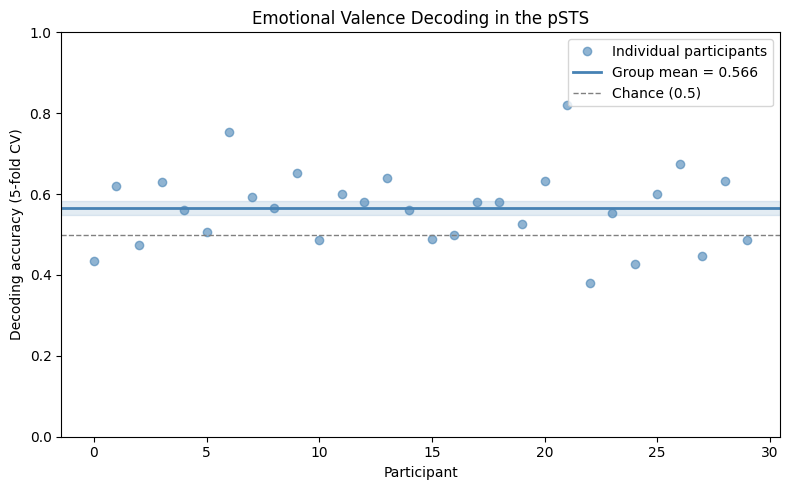

In [ ]:
# Example visualisation: per-participant accuracy in the pSTS
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(results_df['accuracy'].values, 'o', color='steelblue', alpha=0.6, label='Individual participants')

sem = sd_acc / np.sqrt(len(results_df))
ax.axhline(mean_acc, color='steelblue', linewidth=2, label=f'Group mean = {mean_acc:.3f}')
ax.axhspan(mean_acc - sem, mean_acc + sem, color='steelblue', alpha=0.15)
ax.axhline(CHANCE, color='grey', linestyle='--', linewidth=1, label='Chance (0.5)')

ax.set_xlabel('Participant')
ax.set_ylabel('Decoding accuracy (5-fold CV)')
ax.set_title('Emotional Valence Decoding in the pSTS')
ax.legend(loc='upper right')
ax.set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

### Part 1: Code Implementation (30%)
Extend the analysis above. Your implementation should address three questions:

1. **Which additional brain regions carry valence information?** Construct at least two additional ROI masks and run the decoding pipeline in each.
2. **Does classifier choice affect the results?** Implement at least one alternative classifier.
3. **How should decoding performance be compared?** Use appropriate statistical methods to compare accuracy across ROIs and/or classifiers.

Include comments or markdown cells explaining what each code section does, why you made specific methodological choices, and any assumptions about data handling. Ensure code runs without errors.

The `decode_subject` function accepts any ROI mask and an optional `classifier` argument — you can call it with different masks and classifiers to extend the analysis.

In [ ]:
# Your code here


### Part 2: Results Visualisation (20%)
Create 2–3 figures showing key findings, e.g.:
- Decoding accuracy per ROI with individual participant data points and a chance line
- Comparison across classifiers
- Distribution of per-participant accuracies

Include clear figure captions explaining what is shown.

In [ ]:
# Your code here


### Part 3: Interpretation and Reflection (50%)

Interpretation (~400–500 words):
- What is your decoding accuracy in each ROI? Is this high or low, and compared to what?
- Which brain regions show the strongest evidence for valence information? Which do not?
- Does classifier choice meaningfully affect the conclusions?
- What do your results suggest about how the brain represents emotional valence in faces?
- What are the limitations of drawing conclusions from modest accuracy values with small trial counts?

Reflection (~600–800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about multivariate approaches to neuroimaging data?

*You can write your interpretation and reflection in this markdown cell. Feel free to structure it with subheadings or bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*